2026-08-15 17:12:26.565 | INFO     | __main__:fruit_node:33 - ==============================
2026-08-15 17:12:26.565 | INFO     | __main__:vegetable_node:62 - ==============================
2026-08-15 17:12:26.566 | INFO     | __main__:fruit_node:34 - 调用水果子图的 fruit_node 节点，当前的 messages: 
2026-08-15 17:12:26.566 | INFO     | __main__:vegetable_node:63 - 调用蔬菜子图的 vegetable_node 节点，当前的 messages: 
2026-08-15 17:12:26.567 | INFO     | __main__:fruit_node:36 - 
[消息 1]
类型：system
内容：用最简短的话介绍用户输入的水果
2026-08-15 17:12:26.567 | INFO     | __main__:vegetable_node:65 - 
[消息 1]
类型：system
内容：用最简短的话介绍用户输入的蔬菜
2026-08-15 17:12:26.567 | INFO     | __main__:fruit_node:36 - 
[消息 2]
类型：human
内容：桑葚
2026-08-15 17:12:26.568 | INFO     | __main__:vegetable_node:65 - 
[消息 2]
类型：human
内容：西兰苔
2026-08-15 17:12:26.568 | INFO     | __main__:fruit_node:44 - ==============================
2026-08-15 17:12:26.569 | INFO     | __main__:vegetable_node:73 - ==============================
============================== -> 第一次

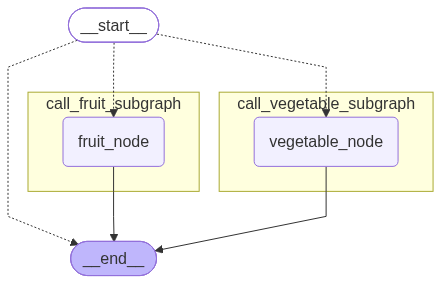

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	__end__([<p>__end__</p>]):::last
	__start__ -.-> __end__;
	__start__ -.-> call_fruit_subgraph\3afruit_node;
	__start__ -.-> call_vegetable_subgraph\3avegetable_node;
	call_fruit_subgraph\3afruit_node --> __end__;
	call_vegetable_subgraph\3avegetable_node --> __end__;
	subgraph call_fruit_subgraph
	call_fruit_subgraph\3afruit_node(fruit_node)
	end
	subgraph call_vegetable_subgraph
	call_vegetable_subgraph\3avegetable_node(vegetable_node)
	end
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [1]:
from typing import TypedDict, Literal
from collections.abc import Sequence
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from langchain.messages import HumanMessage, SystemMessage, AIMessage
from langchain_deepseek import ChatDeepSeek

import sys
from loguru import logger
logger.remove()
logger.add(sys.stdout, colorize=True)

import os
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
load_dotenv(override=True)
from rich import print as rprint

GEMINI_API_KEY=os.getenv("GEMINI_API_KEY")
GEMINI_BASE_URL=os.getenv("GEMINI_BASE_URL")

model = init_chat_model(
  model="gemini-2.5-flash",
  model_provider="google_genai",
  api_key=GEMINI_API_KEY,
  transport="rest"  # 强制使用 REST 协议
)

# 构建水果子图
def fruit_node(state: MessagesState) -> MessagesState:
    messages = state["messages"]
    logger.info("=" * 30)
    logger.info("调用水果子图的 fruit_node 节点，当前的 messages: ")
    for index, message in enumerate(messages, start=1):
        logger.opt(colors=True).info(
            "\n<cyan><bold>[消息 {}]</bold></cyan>\n"
            "<yellow>类型：</yellow><magenta>{}</magenta>\n"
            "<yellow>内容：</yellow><green>{}</green>",
            index,
            message.type,
            message.content
        )
    logger.info("=" * 30)
    response = model.invoke(input=messages)
    ai_msg = AIMessage(content=response.content)

    return {
        "messages": [ai_msg]
    }

builder = StateGraph(state_schema=MessagesState)
builder.add_node("fruit_node", fruit_node)
builder.add_edge(START, "fruit_node")
builder.add_edge("fruit_node", END)

fruit_subgraph = builder.compile(checkpointer=True)

# 构建蔬菜子图
def vegetable_node(state: MessagesState) -> MessagesState:
    messages = state["messages"]
    logger.info("=" * 30)
    logger.info("调用蔬菜子图的 vegetable_node 节点，当前的 messages: ")
    for index, message in enumerate(messages, start=1):
        logger.opt(colors=True).info(
            "\n<cyan><bold>[消息 {}]</bold></cyan>\n"
            "<yellow>类型：</yellow><magenta>{}</magenta>\n"
            "<yellow>内容：</yellow><green>{}</green>",
            index,
            message.type,
            message.content
        )
    logger.info("=" * 30)
    response = model.invoke(input=messages)
    ai_msg = AIMessage(content=response.content)

    return {
        "messages": [ai_msg]
    }

builder = StateGraph(state_schema=MessagesState)
builder.add_node("vegetable_node", vegetable_node)
builder.add_edge(START, "vegetable_node")
builder.add_edge("vegetable_node", END)

vegetable_subgraph = builder.compile(checkpointer=True)

# 构建父图
class OverAllState(TypedDict):
    fruit: str # 水果
    vegetable: str # 蔬菜

    fruit_introduction: str # 水果介绍
    vegetable_introduction: str # 蔬菜介绍

def call_fruit_subgraph(state: OverAllState) -> OverAllState:
    fruit = state["fruit"]

    fruit_messages = [
        SystemMessage("用最简短的话介绍用户输入的水果"),
        HumanMessage(fruit)
    ]

    fruit_response = fruit_subgraph.invoke({"messages": fruit_messages})
    fruit_introduction = fruit_response["messages"][-1].content

    return {
        "fruit_introduction": fruit_introduction
    }

def call_vegetable_subgraph(state: OverAllState) -> OverAllState:
    vegetable = state["vegetable"]

    vegetable_messages = [
        SystemMessage("用最简短的话介绍用户输入的蔬菜"),
        HumanMessage(vegetable)
    ]

    vegetable_response = vegetable_subgraph.invoke({"messages": vegetable_messages})
    vegetable_introduction = vegetable_response["messages"][-1].content

    return {
        "vegetable_introduction": vegetable_introduction
    }

def router(state: OverAllState) -> Sequence[Literal["call_fruit_subgraph", "call_vegetable_subgraph", END]]:
    next_nodes = []
    if state.get("fruit"):
        next_nodes.append("call_fruit_subgraph")
    if state.get("vegetable"):
        next_nodes.append("call_vegetable_subgraph")
    if not next_nodes:
        next_nodes.append(END)
    return next_nodes

builder = StateGraph(state_schema=OverAllState)
builder.add_node("call_fruit_subgraph", call_fruit_subgraph)
builder.add_node("call_vegetable_subgraph", call_vegetable_subgraph)

builder.add_conditional_edges(START, router, path_map=["call_fruit_subgraph", "call_vegetable_subgraph", END])
builder.add_edge("call_fruit_subgraph", END)
builder.add_edge("call_vegetable_subgraph", END)

checkpointer = InMemorySaver()
parent_graph = builder.compile(checkpointer=checkpointer)

config = {"configurable": {"thread_id": "independent-nodes-demo"}}

first_response = parent_graph.invoke(
    {
        "fruit": "桑葚",
        "vegetable": "西兰苔"
    },
    config = config
)
print("=" * 30, "-> 第一次运行结果 <-", "=" * 30)
print(first_response)

second_response = parent_graph.invoke(
    {
        "fruit": "香蕉",
        "vegetable": "西兰花"
    },
    config = config
)
print("=" * 30, "-> 第二次运行结果 <-", "=" * 30)
print(second_response)

from IPython.display import display, Image
display(
    Image(
        parent_graph
        .get_graph(xray=True)
        .draw_mermaid_png()
    )
)
raw_mermaid = parent_graph.get_graph(xray=True).draw_mermaid()
print(raw_mermaid)